<a href="https://colab.research.google.com/github/Suruchi7777/Neural-Network-and-Deep-Learning-Assignment3/blob/main/Neural_Network_and_Deep_Learning_Home_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part II — Programming Questions

## Question 1 — Implement Convolution from Scratch

Write a Python program that performs **2-D convolution/filtering** without using a built-in convolution function.

### Input Matrix

\[
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 \\
0 & 1 & 1 & 1 & 0 \\
0 & 0 & 1 & 1 & 1 \\
0 & 0 & 1 & 1 & 0 \\
0 & 1 & 1 & 0 & 0
\end{bmatrix}
\]

### Filter

\[
\begin{bmatrix}
1 & 0 & 1 \\
0 & 1 & 0 \\
1 & 0 & 1
\end{bmatrix}
\]

Use the following parameters:

- **Stride:** 1
- **Padding:** 0

### Requirements

The program must:

1. Store the input matrix and filter using NumPy arrays.
2. Slide the filter over the input matrix.
3. Compute the dot product at every valid location.
4. Print the complete output feature map.
5. Print the output shape.
6. Briefly explain how changing the stride from 1 to 2 would affect the output.

In [1]:
import numpy as np

# Store the input matrix as a NumPy array
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

# Store the filter as a NumPy array
filter_matrix = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

stride = 1
padding = 0

# Get the dimensions of the input and filter
input_height, input_width = input_matrix.shape
filter_height, filter_width = filter_matrix.shape

# Calculate output dimensions
output_height = ((input_height - filter_height + 2 * padding) // stride) + 1
output_width = ((input_width - filter_width + 2 * padding) // stride) + 1

# Create an empty output feature map
output = np.zeros((output_height, output_width), dtype=int)

# Slide the filter over the input matrix
for i in range(output_height):
    for j in range(output_width):
        row_start = i * stride
        row_end = row_start + filter_height

        column_start = j * stride
        column_end = column_start + filter_width

        # Select the current region of the input
        current_region = input_matrix[
            row_start:row_end,
            column_start:column_end
        ]

        # Compute the dot product
        output[i, j] = np.sum(current_region * filter_matrix)

# Print the results
print("Input matrix:")
print(input_matrix)

print("\nFilter:")
print(filter_matrix)

print("\nOutput feature map:")
print(output)

print("\nOutput shape:", output.shape)

Input matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Filter:
[[1 0 1]
 [0 1 0]
 [1 0 1]]

Output feature map:
[[4 3 4]
 [2 4 3]
 [2 3 4]]

Output shape: (3, 3)


## Question 2 — Transfer Learning: Freeze vs. Fine-Tune

Use a pretrained model such as **ResNet18, ResNet50, VGG16**, or another standard pretrained CNN.

Use an image-classification dataset containing at least two classes.

### Experiment A — Feature Extraction

- Load the pretrained network.
- Freeze the convolutional/base layers.
- Replace the final classification layer.
- Train only the new classifier.

### Experiment B — Fine-Tuning

- Start with the pretrained network.
- Unfreeze at least the final convolutional block.
- Train the unfrozen layers and the new classifier.

### Requirements for Both Experiments

1. Report the number of trainable parameters.
2. Train both models for the same number of epochs.
3. Record the training time.
4. Report the test or validation accuracy.
5. Plot the training loss.
6. Compare the two approaches using the following table:

| Method | Trainable Parameters | Training Time | Accuracy |
|---|---:|---:|---:|
| Frozen Feature Extractor |  |  |  |
| Fine-Tuned Network |  |  |  |

### Discussion

In **5–8 sentences**, discuss the results. Explain why freezing layers and fine-tuning layers may produce different training times and performance.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Reproducibility
tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

# CIFAR-10 labels:
# 3 = cat
# 5 = dog
selected_classes = [3, 5]

# Keep only cat and dog images
train_mask = np.isin(y_train, selected_classes)
test_mask = np.isin(y_test, selected_classes)

x_train = x_train[train_mask]
y_train = y_train[train_mask]

x_test = x_test[test_mask]
y_test = y_test[test_mask]

# Convert labels:
# cat (3) -> 0
# dog (5) -> 1
y_train = (y_train == 5).astype(np.float32)
y_test = (y_test == 5).astype(np.float32)

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Test labels:", y_test.shape)

Training images: (10000, 32, 32, 3)
Test images: (2000, 32, 32, 3)
Training labels: (10000,)
Test labels: (2000,)


In [5]:
IMAGE_SIZE = (96, 96)
BATCH_SIZE = 64
EPOCHS = 5

def prepare_image(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((x_train, y_train))
    .shuffle(len(x_train), seed=42)
    .map(prepare_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices((x_test, y_test))
    .map(prepare_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training dataset prepared.")
print("Test dataset prepared.")

Training dataset prepared.
Test dataset prepared.


In [6]:
def count_trainable_parameters(model):
    return int(
        np.sum([
            np.prod(variable.shape)
            for variable in model.trainable_weights
        ])
    )

##Experiment A - Feature Extraction

In [7]:
# Load pretrained ResNet50 without its original classifier
base_model_a = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze all convolutional/base layers
base_model_a.trainable = False

# Add a new binary classifier
inputs = Input(shape=(96, 96, 3), name="Input_Layer")

# training=False keeps Batch Normalization in inference mode
x = base_model_a(inputs, training=False)
x = GlobalAveragePooling2D(name="Global_Average_Pooling")(x)
x = Dropout(0.3, name="Dropout")(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="Binary_Classifier"
)(x)

frozen_model = Model(
    inputs,
    outputs,
    name="Frozen_Feature_Extractor"
)

frozen_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

frozen_parameters = count_trainable_parameters(frozen_model)

print("Frozen-model trainable parameters:", f"{frozen_parameters:,}")

frozen_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Frozen-model trainable parameters: 2,049


Model: "Frozen_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Global_Average_Pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Binary_Classifier (Dense)       │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
start_time = time.perf_counter()

history_frozen = frozen_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

frozen_training_time = time.perf_counter() - start_time

frozen_test_loss, frozen_test_accuracy = frozen_model.evaluate(
    test_dataset,
    verbose=0
)

print("\nExperiment A results")
print("--------------------")
print("Trainable parameters:", f"{frozen_parameters:,}")
print("Training time:", f"{frozen_training_time:.2f} seconds")
print("Test loss:", f"{frozen_test_loss:.4f}")
print("Test accuracy:", f"{frozen_test_accuracy:.4f}")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 438s 3s/step - accuracy: 0.7996 - loss: 0.5167 - val_accuracy: 0.8475 - val_loss: 0.3963
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 445s 3s/step - accuracy: 0.8451 - loss: 0.3806 - val_accuracy: 0.8480 - val_loss: 0.3688
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.8568 - loss: 0.3393 - val_accuracy: 0.8615 - val_loss: 0.3404
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 436s 3s/step - accuracy: 0.8626 - loss: 0.3198 - val_accuracy: 0.8490 - val_loss: 0.3494
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.8678 - loss: 0.3172 - val_accuracy: 0.8625 - val_loss: 0.3302

Experiment A results
--------------------
Trainable parameters: 2,049
Training time: 2190.40 seconds
Test loss: 0.3302
Test accuracy: 0.8625


##Experiment B — Fine-Tuning

In [9]:
# Save the feature-extraction weights
frozen_model.save_weights("feature_extractor.weights.h5")

# Build a separate model for a fair comparison
base_model_b = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

inputs = Input(shape=(96, 96, 3), name="Input_Layer")

x = base_model_b(inputs, training=False)
x = GlobalAveragePooling2D(name="Global_Average_Pooling")(x)
x = Dropout(0.3, name="Dropout")(x)

outputs = Dense(
    1,
    activation="sigmoid",
    name="Binary_Classifier"
)(x)

fine_tuned_model = Model(
    inputs,
    outputs,
    name="Fine_Tuned_ResNet50"
)

# Load the weights learned during Experiment A
fine_tuned_model.load_weights("feature_extractor.weights.h5")

# First freeze every layer in the base network
base_model_b.trainable = True

for layer in base_model_b.layers:
    layer.trainable = False

# Unfreeze the final convolutional block
for layer in base_model_b.layers:
    if layer.name.startswith("conv5_block3"):
        layer.trainable = True

# Keep Batch Normalization layers frozen
for layer in base_model_b.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tuned_parameters = count_trainable_parameters(fine_tuned_model)

print("Fine-tuned model trainable parameters:",
      f"{fine_tuned_parameters:,}")

print("\nUnfrozen ResNet50 layers:")

for layer in base_model_b.layers:
    if layer.trainable:
        print(layer.name)

fine_tuned_model.summary()

Fine-tuned model trainable parameters: 4,461,569

Unfrozen ResNet50 layers:
conv5_block3_1_conv
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_add
conv5_block3_out


Model: "Fine_Tuned_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Global_Average_Pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Binary_Classifier (Dense)       │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 4,461,569 (17.02 MB)

 Non-trainable params: 19,128,192 (72.97 MB)

In [10]:
start_time = time.perf_counter()

history_fine_tuned = fine_tuned_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

fine_tuned_training_time = time.perf_counter() - start_time

fine_tuned_test_loss, fine_tuned_test_accuracy = fine_tuned_model.evaluate(
    test_dataset,
    verbose=0
)

print("\nExperiment B results")
print("--------------------")
print("Trainable parameters:", f"{fine_tuned_parameters:,}")
print("Training time:", f"{fine_tuned_training_time:.2f} seconds")
print("Test loss:", f"{fine_tuned_test_loss:.4f}")
print("Test accuracy:", f"{fine_tuned_test_accuracy:.4f}")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 567s 4s/step - accuracy: 0.8834 - loss: 0.2767 - val_accuracy: 0.8670 - val_loss: 0.3099
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 560s 4s/step - accuracy: 0.8940 - loss: 0.2474 - val_accuracy: 0.8675 - val_loss: 0.3078
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 550s 3s/step - accuracy: 0.9067 - loss: 0.2182 - val_accuracy: 0.8700 - val_loss: 0.3072
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.9151 - loss: 0.1977 - val_accuracy: 0.8710 - val_loss: 0.3105
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 551s 3s/step - accuracy: 0.9299 - loss: 0.1685 - val_accuracy: 0.8775 - val_loss: 0.3111

Experiment B results
--------------------
Trainable parameters: 4,461,569
Training time: 2812.44 seconds
Test loss: 0.3111
Test accuracy: 0.8775


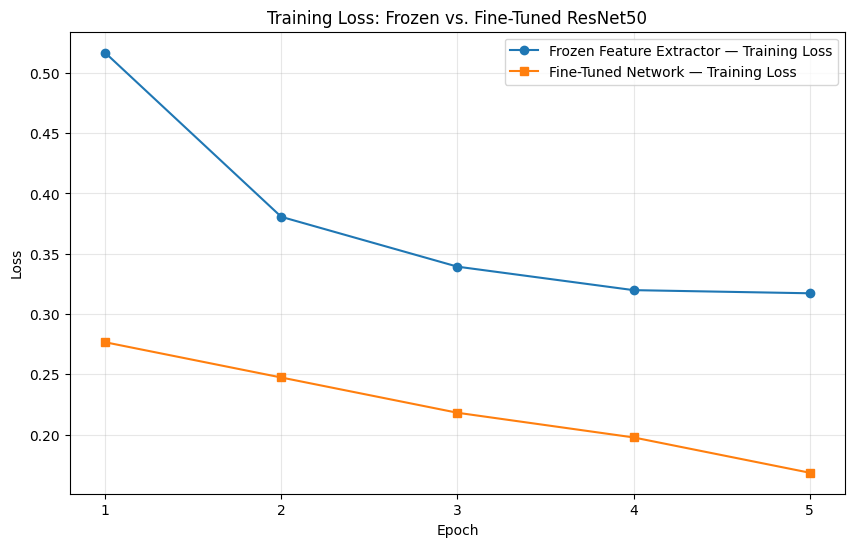

In [11]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_frozen.history["loss"],
    marker="o",
    label="Frozen Feature Extractor — Training Loss"
)

plt.plot(
    epochs_range,
    history_fine_tuned.history["loss"],
    marker="s",
    label="Fine-Tuned Network — Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: Frozen vs. Fine-Tuned ResNet50")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

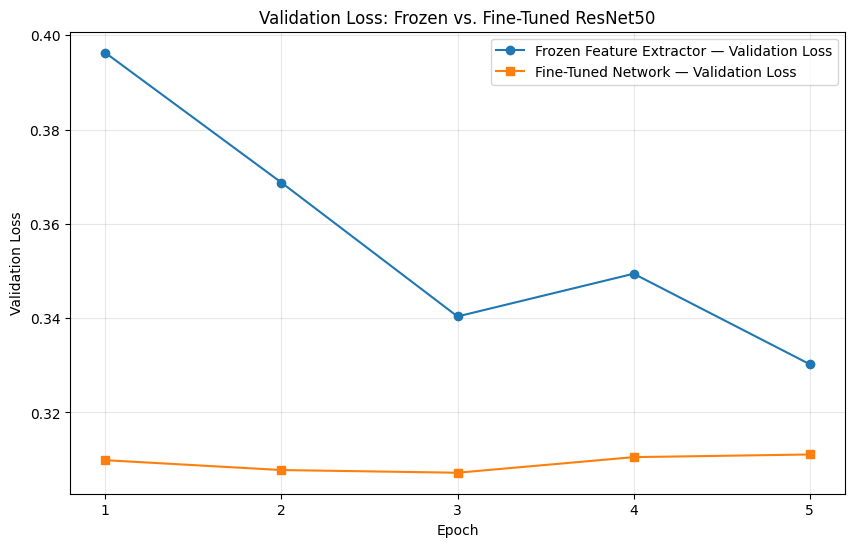

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_frozen.history["val_loss"],
    marker="o",
    label="Frozen Feature Extractor — Validation Loss"
)

plt.plot(
    epochs_range,
    history_fine_tuned.history["val_loss"],
    marker="s",
    label="Fine-Tuned Network — Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Frozen vs. Fine-Tuned ResNet50")
plt.xticks(epochs_range)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [13]:
comparison_table = pd.DataFrame({
    "Method": [
        "Frozen Feature Extractor",
        "Fine-Tuned Network"
    ],
    "Trainable Parameters": [
        frozen_parameters,
        fine_tuned_parameters
    ],
    "Training Time (seconds)": [
        round(frozen_training_time, 2),
        round(fine_tuned_training_time, 2)
    ],
    "Accuracy": [
        round(frozen_test_accuracy, 4),
        round(fine_tuned_test_accuracy, 4)
    ]
})

comparison_table

,Method,Trainable Parameters,Training Time (seconds),Accuracy
0,Frozen Feature Extractor,2049,2190.40,0.8625
1,Fine-Tuned Network,4461569,2812.44,0.8775
